In [1]:
# HOMEWORK9
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
df = pd.read_csv("noisy_curvefit_data.csv")
df

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
0,-1.000000,11.624419,8.296963,12.201067,7.811725,3.155566
1,-0.929293,10.377466,9.674440,12.198084,8.275006,7.518855
2,-0.858586,10.585100,9.251983,13.186565,12.926586,9.963630
3,-0.787879,10.913928,7.786344,12.552304,11.832379,9.625801
4,-0.717172,8.640287,8.551869,4.741432,8.790834,6.624113
...,...,...,...,...,...,...
95,5.717172,-1.411918,0.822231,-2.027132,-1.825106,2.746147
96,5.787879,0.344879,-1.718956,2.747559,-6.803779,-5.137472
97,5.858586,0.307133,0.353528,0.967976,5.461567,-0.905616
98,5.929293,0.048657,0.159961,2.482130,-0.414616,-4.334548


In [3]:
df.shape   #100 rows, 6 columns

(100, 6)

In [4]:
df.head()

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
0,-1.000000,11.624419,8.296963,12.201067,7.811725,3.155566
1,-0.929293,10.377466,9.674440,12.198084,8.275006,7.518855
2,-0.858586,10.585100,9.251983,13.186565,12.926586,9.963630
3,-0.787879,10.913928,7.786344,12.552304,11.832379,9.625801
4,-0.717172,8.640287,8.551869,4.741432,8.790834,6.624113


In [5]:
df.tail()

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
95,5.717172,-1.411918,0.822231,-2.027132,-1.825106,2.746147
96,5.787879,0.344879,-1.718956,2.747559,-6.803779,-5.137472
97,5.858586,0.307133,0.353528,0.967976,5.461567,-0.905616
98,5.929293,0.048657,0.159961,2.482130,-0.414616,-4.334548
99,6.000000,-0.193438,-2.244792,1.930035,4.992414,-6.872850


In [6]:
df.columns

Index(['x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5'], dtype='object')

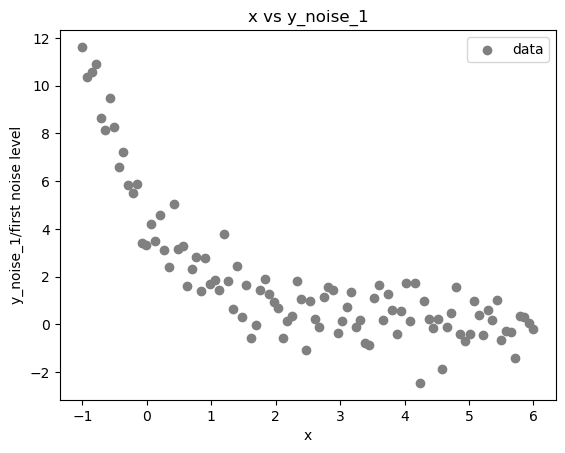

In [7]:
plt.figure()
x=df['x']
y=df['y_noise_1']
plt.scatter(x, y, c='gray', label = "data")
plt.title("x vs y_noise_1")
plt.xlabel("x")
plt.ylabel("y_noise_1/first noise level")
plt.legend()

In [8]:
def model(x, A, k):
    return A* np.exp(-k*x)
p0=[1,1]
popt, pcov = curve_fit(model, x, y, p0=p0)

In [9]:
A_fit, k_fit = popt
print(f"Fit: y={A_fit:.2f} * e^(-{k_fit:.2f}*x)")

Fit: y=4.71 * e^(-0.92*x)


In [43]:
residuals = y - model(x, A_fit, k_fit)
chi2 = np.sum(residuals **2)
dof = len(x) - len(popt)
chi2_reduced = chi2/dof

np.float64(0.7906732087457313)

In [11]:
from math import e

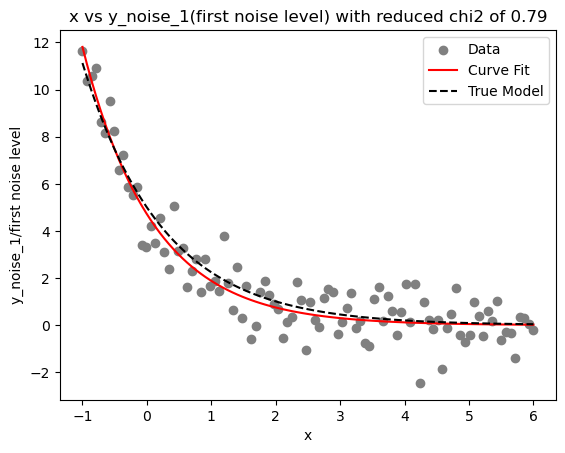

In [12]:
plt.figure()
plt.scatter(df['x'],df['y_noise_1'], c='gray', label = "Data")
plt.plot(x, A_fit * e**(-(k_fit) * x), c='r', label="Curve Fit")
plt.plot(x, model(x, 5, 0.8), c='black', linestyle = "--", label = 'True Model')
plt.title(f"x vs y_noise_1(first noise level) with reduced chi2 of {chi2_reduced:.2f}")
plt.xlabel("x")
plt.ylabel("y_noise_1/first noise level")
plt.legend()

In [16]:
#2.3 --- Compare Different Noise  Levels ---

In [13]:
def model(x, A, k):
    return A* np.exp(-k*x)
p0=[1,1]
popt, pcov = curve_fit(model, x, y, p0=p0)

A_fit, k_fit = popt

def fit_model(x, y):
    popt, pcov = curve_fit(model, x, y, p0=p0)
    A_fit, k_fit = popt
    fit_curve =  A_fit * e**(-(k_fit) * x)
    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals **2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2/dof
    return popt, chi2_reduced
fit_model(df['x'],df['y_noise_1'])    #test, parameters (4.71, 0.79), reduced chi squared = 0.79

(array([4.71481388, 0.91830785]), np.float64(0.7906732087457313))

C:\Users\yangc\AppData\Local\Temp\ipykernel_23144\4147058074.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


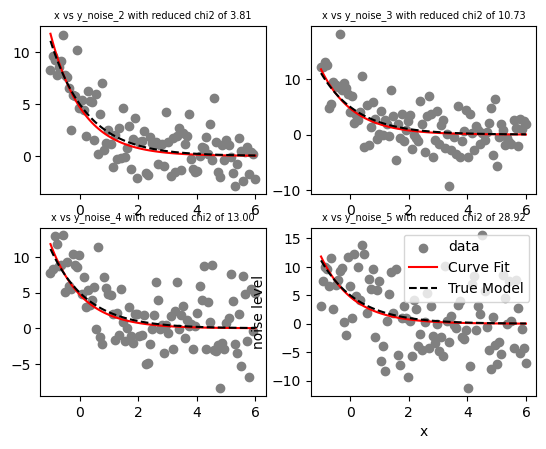

In [32]:
fig, ax= plt.subplots(2,2)
df = pd.read_csv("noisy_curvefit_data.csv")
x_val = df.pop('x').values
new_df = df.pop('y_noise_1')

def model(x, A, k):
    return A* np.exp(-k*x)
p0=[1,1]
popt, pcov = curve_fit(model, x_val, y, p0=p0)

A_fit, k_fit = popt

for i, colname in enumerate(df):
    r = i//2
    c = i%2
    ax[r,c].scatter(x_val, df[colname], c='grey', label='data')
    ax[r,c].plot(x_val, A_fit * e**(-(k_fit) * x), c='r', label="Curve Fit")
    ax[r,c].plot(x_val, model(x, 5, 0.8), c='black', linestyle = "--", label = 'True Model')

    residuals = df[colname] - model(x_val, A_fit, k_fit)
    chi2 = np.sum(residuals **2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2/dof
    ax[r,c].set_title(f'x vs {colname} with reduced chi2 of {chi2_reduced:.2f}', size=7)
    plt.xlabel("x")
    plt.ylabel("noise level")
    plt.legend()
plt.show()

In [30]:
#As you increase the noise level, the red and black dotted lines become more similar (less error between the line of best fit and the true fit.
#The reduced chi squared increases with each noise level because error/spread of datapoints is increasing.

In [59]:
#2.4 --- Save Your Results ---
data = {
    "Noise Level": ['y_noise_1','y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5'],
    "A_fit": [{A_fit:.2},5.06 , 5.61 , 5.74, 4.94], 
    "k_fit": [{k_fit:.2}, 0.73 , 0.87 , 0.73, 0.70],
    "Reduced chi-squared": [chi2_reduced, 3.65, 10.41 , 12.63 , 28.54]
}
df24 =pd.DataFrame(data)
df24.to_csv("noisy_parameters.csv", index=False)

In [51]:
df = pd.read_csv("noisy_curvefit_data.csv")
df

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
0,-1.000000,11.624419,8.296963,12.201067,7.811725,3.155566
1,-0.929293,10.377466,9.674440,12.198084,8.275006,7.518855
2,-0.858586,10.585100,9.251983,13.186565,12.926586,9.963630
3,-0.787879,10.913928,7.786344,12.552304,11.832379,9.625801
4,-0.717172,8.640287,8.551869,4.741432,8.790834,6.624113
...,...,...,...,...,...,...
95,5.717172,-1.411918,0.822231,-2.027132,-1.825106,2.746147
96,5.787879,0.344879,-1.718956,2.747559,-6.803779,-5.137472
97,5.858586,0.307133,0.353528,0.967976,5.461567,-0.905616
98,5.929293,0.048657,0.159961,2.482130,-0.414616,-4.334548


In [56]:
def model(x, A, k):
    return A* np.exp(-k*x)
p0=[1,1]
popt, pcov = curve_fit(model, x, y, p0=p0)

A_fit, k_fit = popt

def fit_model(x, y):
    popt, pcov = curve_fit(model, x, y, p0=p0)
    A_fit, k_fit = popt
    fit_curve =  A_fit * e**(-(k_fit) * x)
    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals **2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2/dof
    return popt, chi2_reduced
fit_model(df['x'],df['y_noise_5'])     #getting values for dataframe

(array([4.94345847, 0.69501193]), np.float64(28.538124369073678))